In [38]:
import pandas as pd
sales=pd.read_csv(r"D:\foresight\data\raw\sales_daily.csv")
sales.head()
sales.shape
sales.columns
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 548000 entries, 0 to 547999
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   date        548000 non-null  str  
 1   sku_id      548000 non-null  str  
 2   units_sold  548000 non-null  int64
 3   revenue     548000 non-null  int64
 4   unit_price  548000 non-null  int64
 5   promo_flag  548000 non-null  int64
dtypes: int64(4), str(2)
memory usage: 33.4 MB


In [39]:
sales.head(10)
sales.tail(10)

,date,sku_id,units_sold,revenue,unit_price,promo_flag
547990,2025-12-31,SKU491,21,36225,1725,0
547991,2025-12-31,SKU492,7,20454,2922,0
547992,2025-12-31,SKU493,35,78820,2252,0
547993,2025-12-31,SKU494,10,13330,1333,0
547994,2025-12-31,SKU495,5,1435,287,0
547995,2025-12-31,SKU496,21,26019,1239,0
547996,2025-12-31,SKU497,22,59928,2724,0
547997,2025-12-31,SKU498,33,67848,2056,0
547998,2025-12-31,SKU499,11,32032,2912,0
547999,2025-12-31,SKU500,9,18144,2016,0


In [40]:
sales["date"].min(), sales["date"].max()
sales["sku_id"].nunique()
sales["promo_flag"].value_counts()

promo_flag
0    503955
1     44045
Name: count, dtype: int64

In [41]:
sku_master=pd.read_excel(r"D:\foresight\data\raw\sku_master.xlsx")
sku_master.head()
print("duplicates id:",sku_master["sku_id"].duplicated().sum())
# print(sku_master.isnull().sum())

duplicates id: 0


In [42]:
calendar=pd.read_excel(r"D:\foresight\data\raw\calendar.xlsx")
calendar.head()

,date,day_name,week,month,quarter,season,is_weekend,is_holiday,festival,promo_event
0,2025-01-01,Wednesday,1,January,Q1,Winter,No,Yes,New Year,New Year Sale
1,2025-01-02,Thursday,1,January,Q1,Winter,No,No,NaN,NaN
2,2025-01-03,Friday,1,January,Q1,Winter,No,No,NaN,NaN
3,2025-01-04,Saturday,1,January,Q1,Winter,Yes,No,NaN,NaN
4,2025-01-05,Sunday,1,January,Q1,Winter,Yes,No,NaN,NaN


In [43]:
calendar["date"].min(), calendar["date"].max()
calendar.shape[1]
print(calendar["date"].duplicated().sum())
calendar.isnull().sum()

0


date             0
day_name         0
week             0
month            0
quarter          0
season           0
is_weekend       0
is_holiday       0
festival       359
promo_event    359
dtype: int64

In [44]:
inventory=pd.read_excel(r"D:\foresight\data\raw\inventory_snapshots.xlsx")
inventory.head()
print(inventory["date"].min(), inventory["date"].max())
print(inventory["sku_id"].nunique())
print(inventory.duplicated().sum())
print(inventory.isnull().sum())


2025-01-01 2025-12-31
500
0
date              0
sku_id            0
on_hand_units     0
on_order_units    0
lead_time_days    0
reorder_point     0
safety_stock      0
dtype: int64


In [45]:
print(sales["date"].min(), sales["date"].max())
print(calendar["date"].min(), calendar["date"].max())
print(inventory["date"].min(), inventory["date"].max())
print(sales["sku_id"].nunique())
print(sales["sku_id"].nunique())
print(sales["sku_id"].nunique())
sales_skus=set(sales["sku_id"])
master_skus=set(sku_master["sku_id"])
inventory_skus=set(inventory["sku_id"])
print("sales skus not in master skus:",sales_skus-master_skus)
print("sales skus not in master skus:",inventory_skus-master_skus)
duplicates_sales=sales.duplicated(subset=["date","sku_id"]).sum()
print(duplicates_sales)
duplicates_inventory=inventory.duplicated(subset=["date","sku_id"]).sum()
print(duplicates_inventory)

2023-01-01 2025-12-31
2025-01-01 2025-12-31
2025-01-01 2025-12-31
500
500
500
sales skus not in master skus: set()
sales skus not in master skus: set()
0
0


In [46]:
sales["calculated_revenue"]=(sales["units_sold"]*sales["unit_price"])
sales["revenue_diff"]=(sales["revenue"]-sales["calculated_revenue"])
print((sales["revenue_diff"]!=0).sum())
print((sales["units_sold"]<0).sum())
print((sales["revenue"]<0).sum())
print((sales["unit_price"]<0).sum())
print((sales["units_sold"]==0).sum())
print((sales["revenue"]==0).sum())
print((sales["unit_price"]==0).sum())
print(sales["promo_flag"].unique())

0
0
0
0
0
0
0
[0 1]


In [47]:
sales.drop(columns=["calculated_revenue", "revenue_diff"], inplace=True)

In [48]:
sales["date"]=pd.to_datetime(sales["date"])
calendar["date"]=pd.to_datetime(calendar["date"])
inventory["date"]=pd.to_datetime(inventory["date"])
sku_master["launch_date"]=pd.to_datetime(sku_master["launch_date"])
print(sales["date"].dtype)
print(calendar["date"].dtype)
print(inventory["date"].dtype)
print(sku_master["launch_date"].dtype)



datetime64[us]
datetime64[us]
datetime64[us]
datetime64[us]


In [49]:
sales_product=sales.merge(
    sku_master,
    on="sku_id",
    how="left"
    )
print(len(sales))
print(len(sales_product))
sales_product.head()
sales_product.info()
sales_product.isnull().sum()
print(sales_product["date"].min(), sales_product["date"].max())
print(calendar["date"].min(), calendar["date"].max())
print("sales without calendar match",
      len(
    set(sales_product["date"].unique())
    - set(calendar["date"].unique())
))



548000
548000
<class 'pandas.DataFrame'>
RangeIndex: 548000 entries, 0 to 547999
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          548000 non-null  datetime64[us]
 1   sku_id        548000 non-null  str           
 2   units_sold    548000 non-null  int64         
 3   revenue       548000 non-null  int64         
 4   unit_price    548000 non-null  int64         
 5   promo_flag    548000 non-null  int64         
 6   product_name  548000 non-null  str           
 7   category      548000 non-null  str           
 8   subcategory   548000 non-null  str           
 9   launch_date   548000 non-null  datetime64[us]
 10  unit_cost     548000 non-null  int64         
 11  list_price    548000 non-null  int64         
dtypes: datetime64[us](2), int64(6), str(4)
memory usage: 67.9 MB
2023-01-01 00:00:00 2025-12-31 00:00:00
2025-01-01 00:00:00 2025-12-31 00:00:00
sales without calendar mat

In [50]:
missing_calendar_dates=sorted(set(sales_product["date"].unique())-set(calendar["date"].unique()))
print(len(missing_calendar_dates))
print(missing_calendar_dates[:10])
print(missing_calendar_dates[-10:])

731
[Timestamp('2023-01-01 00:00:00'), Timestamp('2023-01-02 00:00:00'), Timestamp('2023-01-03 00:00:00'), Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-05 00:00:00'), Timestamp('2023-01-06 00:00:00'), Timestamp('2023-01-07 00:00:00'), Timestamp('2023-01-08 00:00:00'), Timestamp('2023-01-09 00:00:00'), Timestamp('2023-01-10 00:00:00')]
[Timestamp('2024-12-22 00:00:00'), Timestamp('2024-12-23 00:00:00'), Timestamp('2024-12-24 00:00:00'), Timestamp('2024-12-25 00:00:00'), Timestamp('2024-12-26 00:00:00'), Timestamp('2024-12-27 00:00:00'), Timestamp('2024-12-28 00:00:00'), Timestamp('2024-12-29 00:00:00'), Timestamp('2024-12-30 00:00:00'), Timestamp('2024-12-31 00:00:00')]


In [51]:
sales_full=sales_product.merge(calendar, on="date", how="left")
sales_full.head()
print(len(sales_product))
print(len(sales_full))
print(sales_full.shape)
print(sales_full[sales_full["date"].dt.year==2025]["season"].isna().sum())

548000
548000
(548000, 21)
0


In [52]:
print(len(sales_full))
print((sales_full["date"].dt.year==2025).sum())
print(len(inventory))
print(inventory["date"].min(), inventory["date"].max())
sales_2025=sales_full[sales_full["date"].dt.year==2025].copy()
print(len(sales_2025))
print(sales_2025[["date", "sku_id"]].drop_duplicates().shape[0])
print(inventory[["date", "sku_id"]].drop_duplicates().shape[0])
sales_key=set(zip(sales_2025["date"], sales_2025["sku_id"]))
inventory_key=set(zip(inventory["date"], inventory["sku_id"]))
print(len(sales_key-inventory_key))

548000
182500
182500
2025-01-01 00:00:00 2025-12-31 00:00:00
182500
182500
182500
0


In [53]:
sales_inventory=sales_full.merge(inventory,on=["date", "sku_id"], how="left")
print(len(sales_full))
print(len(sales_inventory))
sales_inventory.shape
print(sales_inventory[["on_hand_units", "on_order_units", "lead_time_days", "reorder_point"]].isnull().sum())

548000
548000
on_hand_units     365500
on_order_units    365500
lead_time_days    365500
reorder_point     365500
dtype: int64


In [54]:
print("total sales revenue:", sales_inventory["revenue"].sum())
print("total units sold:", sales_inventory["units_sold"].sum())
print("unique products:", sales_inventory["sku_id"].nunique())
print("categories:", sales_inventory["category"].unique())

category_sales=(
    sales_inventory.groupby("category")[["revenue", "units_sold"]].sum().sort_values("revenue", ascending=True)
)
category_sales



total sales revenue: 17918484416
total units sold: 10966424
unique products: 500
categories: <ArrowStringArray>
[  'Furniture',     'Kitchen',    'Lighting',  'Home Decor',     'Storage',
     'Bedding',      'Dining',    'Bathroom',      'Garden', 'Electronics']
Length: 10, dtype: str


,revenue,units_sold
category,,
Dining,1568333367,1099683
Bathroom,1718733495,1096628
Lighting,1725204972,1093591
Bedding,1750855343,1095026
Furniture,1808329330,1098865
Kitchen,1812006125,1097447
Electronics,1852739794,1100357
Garden,1876311179,1095726
Home Decor,1893139982,1093767


<Axes: title={'center': 'Monthly Units Sold'}, xlabel='date'>

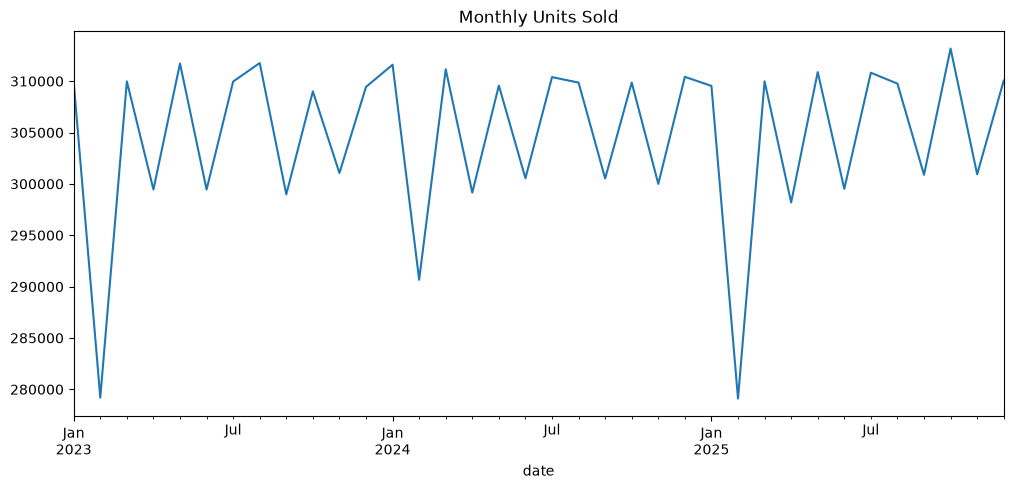

In [55]:
#monthly sales

monthly_sales=(sales_inventory.groupby(sales_inventory["date"].dt.to_period("M"))["units_sold"].sum())
monthly_sales.plot(figsize=(12,5),title="Monthly Units Sold")

In [56]:
top10=(sales_inventory.groupby("sku_id")["revenue"].sum().nlargest(10))
print(top10)
dead_stock=(sales_inventory.groupby("sku_id")["revenue"].sum().nsmallest(10))
print(dead_stock)
promo_analysis=sales_inventory.groupby("promo_flag")["units_sold"].mean()
print(promo_analysis)

sku_id
SKU408    66881052
SKU052    66161634
SKU053    65935380
SKU411    65841347
SKU432    65840697
SKU284    65835744
SKU156    65814000
SKU234    65394368
SKU484    65333140
SKU292    64996640
Name: revenue, dtype: int64
sku_id
SKU418    4447334
SKU065    4483512
SKU392    5010117
SKU026    5069516
SKU042    5102376
SKU282    5343398
SKU299    5371128
SKU423    5372372
SKU261    5389011
SKU003    5472285
Name: revenue, dtype: int64
promo_flag
0    20.014555
1    19.979317
Name: units_sold, dtype: float64


In [57]:
weekly_sales=(sales_inventory.groupby(["sku_id",pd.Grouper(key="date", freq="W")])["units_sold"].sum().reset_index())
weekly_sales.head()
sku408=weekly_sales[weekly_sales["sku_id"]=="SKU408"].copy()
sku408.tail(10)
sku408["naive_forecast"]=sku408["units_sold"].shift(1)
sku408[["date", "units_sold", "naive_forecast"]].tail(10)

,date,units_sold,naive_forecast
64454,2025-11-02,162,90.0
64455,2025-11-09,153,162.0
64456,2025-11-16,139,153.0
64457,2025-11-23,115,139.0
64458,2025-11-30,164,115.0
64459,2025-12-07,141,164.0
64460,2025-12-14,138,141.0
64461,2025-12-21,121,138.0
64462,2025-12-28,123,121.0
64463,2026-01-04,43,123.0


In [58]:
sku408["lag_1"]=sku408["units_sold"].shift(1)
sku408["lag_2"]=sku408["units_sold"].shift(2)
sku408["lag_4"]=sku408["units_sold"].shift(4)
sku408.head(10)
sku408["rolling_4"]=(sku408["units_sold"].rolling(4).mean())
sku408=sku408.dropna().reset_index(drop=True)
sku408.head()



,sku_id,date,units_sold,naive_forecast,lag_1,lag_2,lag_4,rolling_4
0,SKU408,2023-01-29,171,131.0,131.0,136.0,22.0,141.25
1,SKU408,2023-02-05,117,171.0,171.0,131.0,127.0,138.75
2,SKU408,2023-02-12,119,117.0,117.0,171.0,136.0,134.50
3,SKU408,2023-02-19,169,119.0,119.0,117.0,131.0,144.00
4,SKU408,2023-02-26,120,169.0,169.0,119.0,171.0,131.25


In [59]:
from sklearn.metrics import root_mean_squared_error
rsme=root_mean_squared_error(sku408["units_sold"],sku408["naive_forecast"])
print(rsme)

39.869755487053126


In [60]:
X = sku408[["lag_1", "lag_2", "lag_4", "rolling_4"]]
y = sku408["units_sold"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(predictions[:5])

[152.33 123.66 137.79 153.9  115.36]


In [61]:
import numpy as np

wape_ml = (
    np.abs(y_test - predictions).sum()
    / np.abs(y_test).sum()
)

print("ML WAPE:", wape_ml)
print("ML WAPE %:", round(wape_ml * 100, 2), "%")
baseline_test = sku408.iloc[-len(y_test):]

baseline_predictions = baseline_test["naive_forecast"].values

wape_baseline = (
    np.abs(
        baseline_test["units_sold"].values - baseline_predictions
    ).sum()
    / np.abs(baseline_test["units_sold"].values).sum()
)

print("Baseline WAPE:", wape_baseline)
print("Baseline WAPE %:", round(wape_baseline * 100, 2), "%")
print("Baseline WAPE %:", round(wape_baseline * 100, 2))
print("ML WAPE %:", round(wape_ml * 100, 2))

if wape_ml < wape_baseline:
    print("ML model beats the baseline ✅")
else:
    print("Baseline beats the ML model ⚠️")

ML WAPE: 0.134077892325315
ML WAPE %: 13.41 %
Baseline WAPE: 0.24054982817869416
Baseline WAPE %: 24.05 %
Baseline WAPE %: 24.05
ML WAPE %: 13.41
ML model beats the baseline ✅


In [62]:
weekly_sales_all = (
    sales
    .groupby(["sku_id", pd.Grouper(key="date", freq="W")])["units_sold"]
    .sum()
    .reset_index()
    .sort_values(["sku_id", "date"])
)

print(weekly_sales_all.head())
print("Rows:", len(weekly_sales_all))
print("SKUs:", weekly_sales_all["sku_id"].nunique())
weekly_sales_all["lag_1"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .shift(1)
)

weekly_sales_all["lag_2"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .shift(2)
)

weekly_sales_all["lag_4"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .shift(4)
)

weekly_sales_all["rolling_4"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)
weekly_sales_all[
    [
        "sku_id",
        "date",
        "units_sold",
        "lag_1",
        "lag_2",
        "lag_4",
        "rolling_4"
    ]
].head(10)
weekly_model_data = weekly_sales_all.dropna().reset_index(drop=True)

print("Before drop:", len(weekly_sales_all))
print("After drop:", len(weekly_model_data))

   sku_id       date  units_sold
0  SKU001 2023-01-01          23
1  SKU001 2023-01-08         146
2  SKU001 2023-01-15         144
3  SKU001 2023-01-22         187
4  SKU001 2023-01-29         144
Rows: 79000
SKUs: 500
Before drop: 79000
After drop: 77000


In [63]:
weekly_sales_all["seasonal_naive"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .shift(52)
)
test_weeks = 12

last_date = weekly_model_data["date"].max()

test_start = (
    last_date - pd.Timedelta(weeks=test_weeks - 1)
)

train_data = weekly_model_data[
    weekly_model_data["date"] < test_start
].copy()

test_data = weekly_model_data[
    weekly_model_data["date"] >= test_start
].copy()

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))
print("Test start:", test_data["date"].min())
print("Test end:", test_data["date"].max())
from sklearn.ensemble import RandomForestRegressor

features = [
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_4"
]

X_train = train_data[features]
y_train = train_data["units_sold"]

X_test = test_data[features]
y_test = test_data["units_sold"]

model_all = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_all.fit(X_train, y_train)

ml_predictions = model_all.predict(X_test)
ml_wape = (
    np.abs(y_test.values - ml_predictions).sum()
    / np.abs(y_test.values).sum()
)

print("ML WAPE:", round(ml_wape * 100, 2), "%")
test_data["seasonal_naive"]=test_data["lag_1"]
baseline_test = test_data.dropna(
    subset=["seasonal_naive"]
).copy()

baseline_wape = (
    np.abs(
        baseline_test["units_sold"].values
        - baseline_test["seasonal_naive"].values
    ).sum()
    /
    np.abs(
        baseline_test["units_sold"].values
    ).sum()
)

print(
    "Seasonal-naive WAPE:",
    round(baseline_wape * 100, 2),
    "%"
)

Training rows: 71000
Testing rows: 6000
Test start: 2025-10-19 00:00:00
Test end: 2026-01-04 00:00:00
ML WAPE: 18.26 %
Seasonal-naive WAPE: 23.33 %


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

features = [
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_4"
]


weekly_model_data = (
    weekly_model_data
    .sort_values(["sku_id", "date"])
    .reset_index(drop=True)
)


weekly_model_data["seasonal_naive"] = (
    weekly_model_data
    .groupby("sku_id")["units_sold"]
    .shift(52)
)


weeks = sorted(weekly_model_data["date"].unique())


n_folds = 5
test_size = 4

results = []

for fold in range(n_folds):

    # Determine test period
    test_end_index = (
        len(weeks) - (n_folds - fold - 1) * test_size
    )

    test_start_index = test_end_index - test_size

    test_start = weeks[test_start_index]
    test_end = weeks[test_end_index - 1]

    
    train = weekly_model_data[
        weekly_model_data["date"] < test_start
    ].copy()

    
    test = weekly_model_data[
        (weekly_model_data["date"] >= test_start) &
        (weekly_model_data["date"] <= test_end)
    ].copy()

    # Remove rows where ML features are missing
    train_ml = train.dropna(subset=features)
    test_ml = test.dropna(subset=features)

    
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        train_ml[features],
        train_ml["units_sold"]
    )

    predictions = model.predict(
        test_ml[features]
    )

    actual = test_ml["units_sold"].values


    denominator = np.abs(actual).sum()

    if denominator != 0:
        ml_wape = (
            np.abs(actual - predictions).sum()
            / denominator
        )
    else:
        ml_wape = np.nan

    
    baseline_test = test.dropna(
        subset=["seasonal_naive"]
    )

    if len(baseline_test) > 0:

        baseline_actual = (
            baseline_test["units_sold"].values
        )

        baseline_predictions = (
            baseline_test["seasonal_naive"].values
        )

        baseline_denominator = (
            np.abs(baseline_actual).sum()
        )

        if baseline_denominator != 0:
            baseline_wape = (
                np.abs(
                    baseline_actual -
                    baseline_predictions
                ).sum()
                / baseline_denominator
            )
        else:
            baseline_wape = np.nan

    else:
        baseline_wape = np.nan

    
    results.append({
        "fold": fold + 1,
        "test_start": test_start,
        "test_end": test_end,
        "ml_wape": ml_wape,
        "baseline_wape": baseline_wape
    })



results_df = pd.DataFrame(results)

print(results_df)

   fold test_start   test_end   ml_wape  baseline_wape
0     1 2025-08-24 2025-09-14  0.138736       0.187651
1     2 2025-09-21 2025-10-12  0.137738       0.190787
2     3 2025-10-19 2025-11-09  0.138276       0.187869
3     4 2025-11-16 2025-12-07  0.136245       0.191171
4     5 2025-12-14 2026-01-04  0.289993       0.341870


In [65]:
ml_bias = (
    (y_test.values - ml_predictions).sum()
    / y_test.values.sum()
)

print("ML Bias:", round(ml_bias * 100, 2), "%")

ML Bias: -4.51 %


In [66]:
inventory[
    [
        "on_hand_units",
        "on_order_units",
        "lead_time_days",
        "reorder_point"
    ]
].describe()
weekly_sales_all = (
    sales
    .groupby(["sku_id", pd.Grouper(key="date", freq="W")])["units_sold"]
    .sum()
    .reset_index()
    .sort_values(["sku_id", "date"])
)

print("Number of SKUs:", weekly_sales_all["sku_id"].nunique())
print("Number of weekly rows:", len(weekly_sales_all))
print(weekly_sales_all.head())

Number of SKUs: 500
Number of weekly rows: 79000
   sku_id       date  units_sold
0  SKU001 2023-01-01          23
1  SKU001 2023-01-08         146
2  SKU001 2023-01-15         144
3  SKU001 2023-01-22         187
4  SKU001 2023-01-29         144


In [67]:

weekly_sales_all["lag_1"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .shift(1)
)

weekly_sales_all["lag_2"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .shift(2)
)

weekly_sales_all["lag_4"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .shift(4)
)

# Leakage-safe rolling average
weekly_sales_all["rolling_4"] = (
    weekly_sales_all
    .groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

print(
    weekly_sales_all[
        [
            "sku_id",
            "date",
            "units_sold",
            "lag_1",
            "lag_2",
            "lag_4",
            "rolling_4"
        ]
    ].head(10)
)
weekly_model_data = weekly_sales_all.dropna(
    subset=["lag_1", "lag_2", "lag_4", "rolling_4"]
).copy()

print("SKUs:", weekly_model_data["sku_id"].nunique())
print("Rows:", len(weekly_model_data))


   sku_id       date  units_sold  lag_1  lag_2  lag_4  rolling_4
0  SKU001 2023-01-01          23    NaN    NaN    NaN        NaN
1  SKU001 2023-01-08         146   23.0    NaN    NaN        NaN
2  SKU001 2023-01-15         144  146.0   23.0    NaN        NaN
3  SKU001 2023-01-22         187  144.0  146.0    NaN        NaN
4  SKU001 2023-01-29         144  187.0  144.0   23.0     125.00
5  SKU001 2023-02-05         150  144.0  187.0  146.0     155.25
6  SKU001 2023-02-12         148  150.0  144.0  144.0     156.25
7  SKU001 2023-02-19         119  148.0  150.0  187.0     157.25
8  SKU001 2023-02-26         175  119.0  148.0  144.0     140.25
9  SKU001 2023-03-05         132  175.0  119.0  150.0     148.00
SKUs: 500
Rows: 77000


In [68]:
latest_inventory = (
    inventory
    .sort_values("date")
    .groupby("sku_id")
    .tail(1)
    .copy()
)

print("SKUs:", latest_inventory["sku_id"].nunique())

SKUs: 500


In [69]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_4"
]

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    weekly_model_data[features],
    weekly_model_data["units_sold"]
)

print("Final model trained on:", len(weekly_model_data), "rows")


latest_4_weeks = (
    weekly_sales_all
    .sort_values(["sku_id", "date"])
    .groupby("sku_id")
    .tail(4)
    .copy()
)

print(
    "SKUs:",
    latest_4_weeks["sku_id"].nunique()
)

print(
    "Rows:",
    len(latest_4_weeks)
)


latest_4_weeks = latest_4_weeks.sort_values(
    ["sku_id", "date"]
)

next_week_features = (
    latest_4_weeks
    .groupby("sku_id")
    .agg(
        lag_1=("units_sold", "last"),
        lag_2=("units_sold", lambda x: x.iloc[-2]),
        lag_4=("units_sold", "first"),
        rolling_4=("units_sold", "mean")
    )
    .reset_index()
)

print(next_week_features.head())
print("SKUs:", next_week_features["sku_id"].nunique())


next_week_features["forecast_week_1"] = final_model.predict(
    next_week_features[features]
)

print(
    next_week_features[
        ["sku_id", "forecast_week_1"]
    ].head(10)
)

Final model trained on: 77000 rows
SKUs: 500
Rows: 2000
   sku_id  lag_1  lag_2  lag_4  rolling_4
0  SKU001     44    102    147     124.75
1  SKU002     91    156    137     131.00
2  SKU003     57    142    117     115.75
3  SKU004     74    139    125     130.00
4  SKU005     48    110    146     103.50
SKUs: 500
   sku_id  forecast_week_1
0  SKU001          130.765
1  SKU002          149.270
2  SKU003          136.635
3  SKU004          142.660
4  SKU005          143.440
5  SKU006          144.870
6  SKU007          140.975
7  SKU008          139.695
8  SKU009          145.020
9  SKU010          141.265


In [ ]:
forecast_actual = test_data[
    ["sku_id", "date", "units_sold"]
].copy()

forecast_actual["forecast"] = ml_predictions

forecast_actual = forecast_actual.rename(
    columns={"units_sold": "actual"}
)

forecast_actual.to_csv(r"D:\foresight\data\forecast_actual.csv",index=False)

print(forecast_actual.head())
print("SKUs:", forecast_actual["sku_id"].nunique())

     sku_id       date  actual  forecast
142  SKU001 2025-10-19     144    134.72
143  SKU001 2025-10-26      96    142.24
144  SKU001 2025-11-02     168    140.51
145  SKU001 2025-11-09     146    134.51
146  SKU001 2025-11-16     172    137.45
SKUs: 500
